In [159]:
import numpy as np
import cv2

class GMMBackgroundModel:
    def __init__(self, K=3, alpha=0.01, T=0.7, init_sigma=15):
        self.K = K              # 高斯分布个数
        self.alpha = alpha      # 学习率/更新率
        self.T = T              # 背景阈值
        self.init_sigma = init_sigma  # 初始化标准差

        self.means = None
        self.vars = None
        self.weights = None

    def initialize(self, frame):
        h, w, c = frame.shape
        # 初始化：均值为当前帧，方差较大，权重相等
        self.means = np.tile(frame, (self.K, 1, 1, 1)).astype(np.float32)
        self.vars = np.full((self.K, h, w, c), self.init_sigma**2, dtype=np.float32)
        self.weights = np.full((self.K, h, w), 1.0 / self.K, dtype=np.float32)

    def update(self, frame):
        h, w, c = frame.shape
        if self.means is None:
            self.initialize(frame)
            return np.zeros((h, w), dtype=np.uint8)

        # 1. 计算当前像素与各个高斯分布均值的马氏距离（近似）
        # distance^2 = sum((x - mu)^2 / sigma^2)
        diff = frame - self.means  # (K, H, W, C)
        sq_diff = diff**2
        dist_sq = np.sum(sq_diff / (self.vars + 1e-6), axis=3) # (K, H, W)

        # 2. 匹配检查：距离 < 2.5 * sigma (即 dist_sq < 6.25) match 的形状是 (K, H, W)
        match = dist_sq < 6.25

        # 找到每个像素匹配到的第一个高斯分布 (K轴上的索引)
        # 这里简化处理：只更新匹配到的第一个
        match_idx = np.argmax(match, axis=0) # (H, W)
        any_match = np.any(match, axis=0)    # (H, W) 是否有匹配

        # 3. 更新参数
        for k in range(self.K):
            """
            对于第 k个高斯分布，只有当当前像素点满足两个条件时才更新它：
            像素值落在该分布的 2.5sigma范围内（距离够近）。
            它是该像素匹配到的第一个分布（防止一个像素同时更新多个分布）。
            """
            curr_match = (match[k] & (match_idx == k))

            # 更新权重
            """
            这是一个指数加权移动平均
            如果匹配成功 (curr_match=1)：权重会增加。这代表该分布在时间轴上出现的频率变高，更有可能成为背景。
            如果匹配失败 (curr_match=0)：权重会减小。这保证了所有权重的总和趋向于 1，且不活跃的分布会逐渐被淘汰。
            """
            self.weights[k] = (1 - self.alpha) * self.weights[k] + self.alpha * curr_match

            # 更新均值和方差 (仅针对匹配成功的分布)
            # rho = alpha * N(x|mu, sigma) 简化为 alpha
            rho = self.alpha
            self.means[k][curr_match] = (1 - rho) * self.means[k][curr_match] + rho * frame[curr_match]
            self.vars[k][curr_match] = (1 - rho) * self.vars[k][curr_match] + rho * np.sum(sq_diff[k][curr_match], axis=-1, keepdims=True)

        # 对于没有匹配到的像素，替换权重最小的分布
        unmatched = ~any_match
        if np.any(unmatched):
            """
            逻辑：在 k个分布中，权重（Weight）最小的那个代表它是最不经常出现、最不稳定的状态。
            策略：与其保留一个没用的旧模板，不如把它删掉，用来记录这个新出现的像素。

            """
            low_weight_idx = np.argmin(self.weights, axis=0)
            # 对未匹配像素的最小权重分布进行重置
            for k in range(self.K):
                # replace_mask is a Boolean mask (True/False), and its shape is (height, width).
                replace_mask = unmatched & (low_weight_idx == k)
                self.means[k][replace_mask] = frame[replace_mask]
                self.vars[k][replace_mask] = self.init_sigma**2
                self.weights[k][replace_mask] = 0.01 # 给予较小权重

        # 归一化权重
        self.weights /= np.sum(self.weights, axis=0)

        # 4. 前景提取：对高斯分布排序 (w/sigma 越大越可能是背景)
        # 简化：假设排序后的前几个是背景，直到权重之和 > T
        # 这里返回非背景部分
        importance = self.weights / (np.sqrt(np.mean(self.vars, axis=3)) + 1e-6)
        """
        默认情况下，np.argsort 是升序排列的（从小到大）。
        假设某个像素的 3 个高斯分布的重要性分别为：[0.1, 0.8, 0.3]
        直接排序 np.argsort([0.1, 0.8, 0.3])
        返回 [0, 2, 1]（最小的是第0个，最大的是第1个）。
        取负号排序 np.argsort([-0.1, -0.8, -0.3])
        返回 [1, 2, 0]。
        Index 1 (0.8) 排名第一，它是我们最想要的背景模板。
        """
        rank_idx = np.argsort(-importance, axis=0)

        # 构建背景掩码
        is_background = np.zeros((h, w), dtype=bool)
        # 标准的 GMM 算法中，我们会累加排序后的权重，直到总和超过阈值
        cumulative_weight = np.zeros((h, w))
        for k in range(self.K):
            # 找到当前排名第k的索引 只取重要性排名第一的那个高斯分布作为背景。
            curr_rank_k_mask = (rank_idx[0] == k) # 简化：只取权重最大的作为背景
            """
            判定条件：如果一个像素既匹配到了某个高斯分布 (any_match)，且该分布是排名第一的候选人 (curr_rank_k_mask)，那么它就被判定为背景。
            使用 |= (或等于) 是因为我们在循环
            个分布，一旦某个像素在某次循环中被定为背景，它就永远是背景。

            """
            is_background |= (curr_rank_k_mask & any_match)
        """
        # 4. 前景提取：标准的权重累加逻辑
        importance = self.weights / (np.sqrt(np.mean(self.vars, axis=3)) + 1e-6)
        # 得到重要性从高到低排序的索引
        rank_idx = np.argsort(-importance, axis=0)

        h, w = frame.shape[:2]
        is_background = np.zeros((h, w), dtype=bool)
        cumulative_weight = np.zeros((h, w), dtype=np.float32)

        # 按照排名顺序遍历 K 个分布
        for k in range(self.K):
            # 找到在每个位置排名第 k 的那个分布的原始索引
            # 例如在像素(0,0)处，排名第0的可能是第2个高斯分布
            # 我们通过 np.take_along_axis 拿到对应的权重和匹配情况
            k_indices = rank_idx[k:k+1, :, :] # 形状 (1, H, W)

            # 获取当前排名的权重和匹配状态
            curr_weight = np.take_along_axis(self.weights, k_indices, axis=0)[0]
            curr_match = np.take_along_axis(match, k_indices, axis=0)[0]

            # 只有当目前的累加权重还未超过阈值 T 时，该分布才被视为背景候选
            # 如果像素匹配到了这个“候选背景”分布，则判定为背景
            is_background |= (curr_match & (cumulative_weight < self.T))

            # 更新累加权重，供下一次循环判断
            cumulative_weight += curr_weight

        # 返回前景掩码：背景为0（黑），前景为255（白）
        return ((~is_background) * 255).astype(np.uint8)

        """
        # : 运动的物体（前景）显示为白色，静止的背景显示为黑色。
        return ((~is_background) * 255).astype(np.uint8)


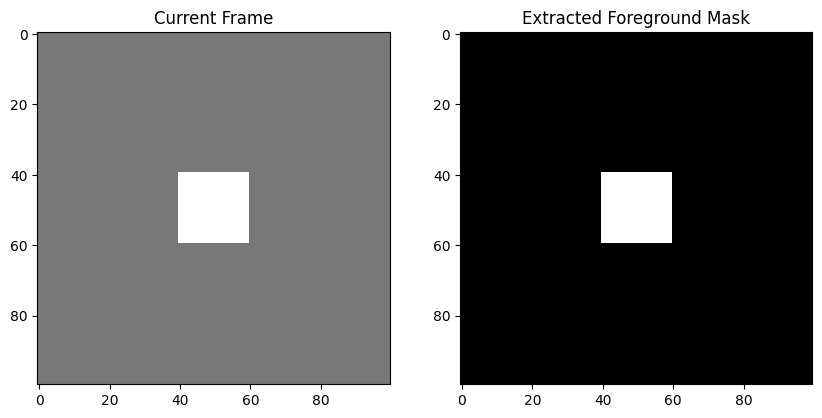

In [160]:
import matplotlib.pyplot as plt

# 1. Create a dummy background (gray image)
height, width = 100, 100
background = np.full((height, width, 3), 120, dtype=np.uint8)

# 2. Initialize the model
model = GMMBackgroundModel(K=3, alpha=0.02)

# 3. Simulate 10 frames of background to let the model stabilize
for _ in range(10):
    _ = model.update(background)

# 4. Create a frame with a 'moving object' (a white square)
frame_with_obj = background.copy()
frame_with_obj[40:60, 40:60] = [255, 255, 255]

# 5. Get the foreground mask
fg_mask = model.update(frame_with_obj)

# 6. Visualize results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Current Frame")
plt.imshow(frame_with_obj)

plt.subplot(1, 2, 2)
plt.title("Extracted Foreground Mask")
plt.imshow(fg_mask, cmap='gray')
plt.show()

In [ ]:
def test_gmm(video_path, K=3, alpha=0.01):
    cap = cv2.VideoCapture(video_path)
    model = GMMBackgroundModel(K=K, alpha=alpha)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        # 缩小尺寸加快速度
        frame = cv2.resize(frame, (320, 240))
        fg_mask = model.update(frame)

        cv2.imshow('Original', frame)
        cv2.imshow('FG Mask', fg_mask)

        if cv2.waitKey(1) & 0xFF == ord('q'): break
    cap.release()
    cv2.destroyAllWindows()
